<a href="https://colab.research.google.com/github/nunez1405/Data-science-projects/blob/main/distraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sehaj1104/student-productivity-and-digital-distraction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-productivity-and-digital-distraction-dataset' dataset.
Path to dataset files: /kaggle/input/student-productivity-and-digital-distraction-dataset


In [ ]:
!pip install --upgrade kagglehub

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import os


In [ ]:
import os

dataset_files = os.listdir(path)
print("Files in dataset directory:", dataset_files)

Files in dataset directory: ['student_productivity_distraction_dataset_20000.csv']


In [ ]:
df = pd.read_csv(os.path.join(path, dataset_files[0]))
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

In [ ]:
df.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [ ]:
print(df.duplicated().any())

False


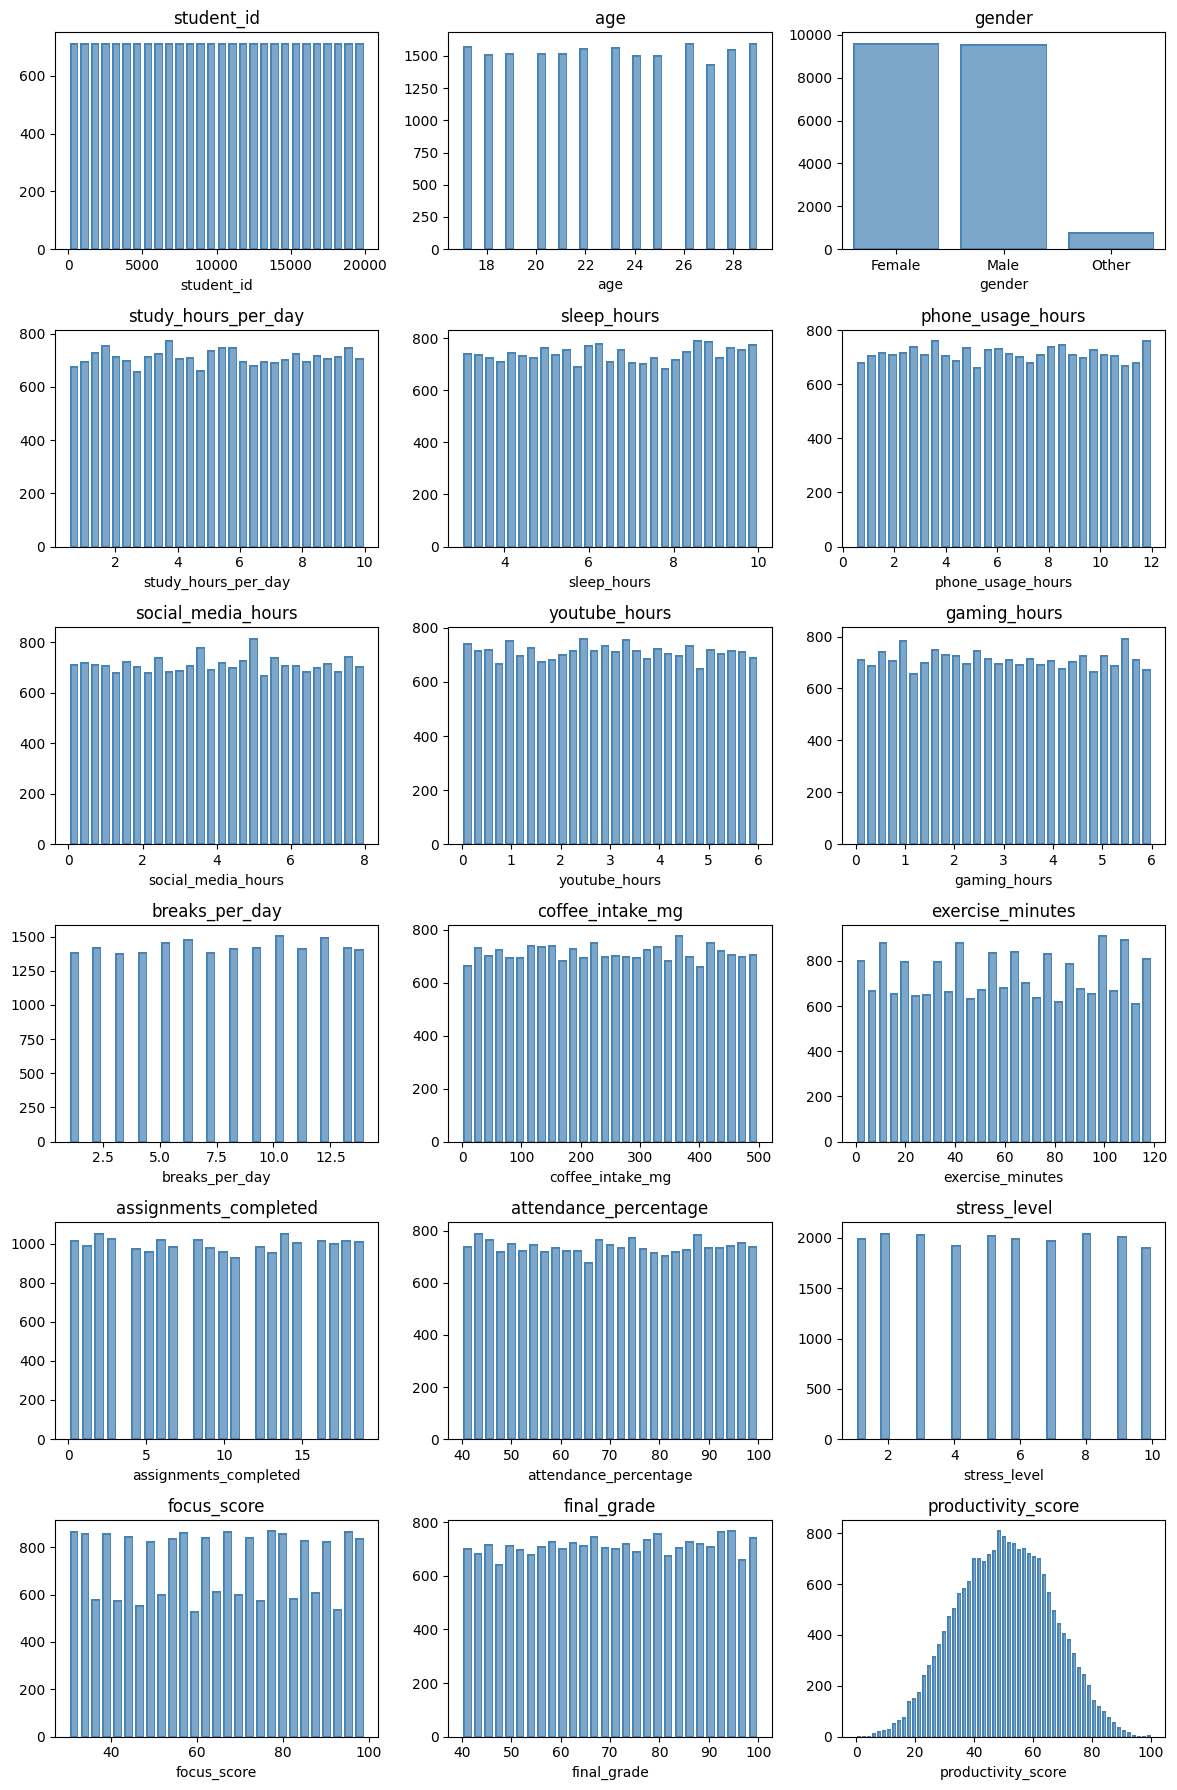

In [ ]:
import matplotlib.pyplot as plt
import math

cols = df.columns
n = len(cols)
ncols = 3  # columnas por fila
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    (
        so.Plot(df, x=col)
        .add(so.Bar(color="steelblue"), so.Hist())
        .label(title=col)
        .on(axes[i])
        .plot()
    )

# Ocultar ejes vacíos si las columnas no son múltiplo de ncols
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

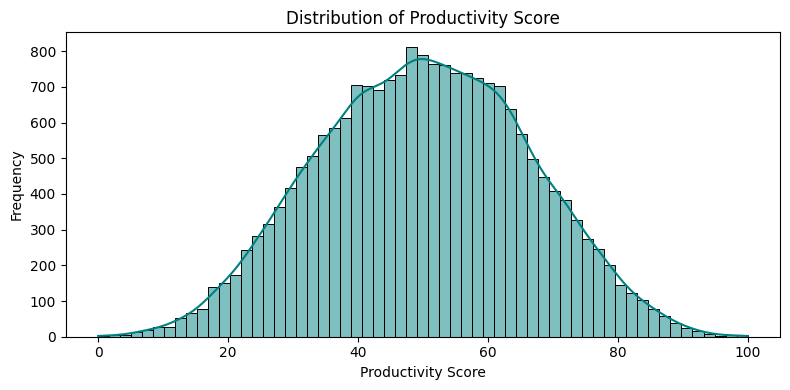

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['productivity_score'], kde=True, color='teal')
plt.title('Distribution of Productivity Score')
plt.xlabel('Productivity Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('productivity_distribution.png')
plt.show()

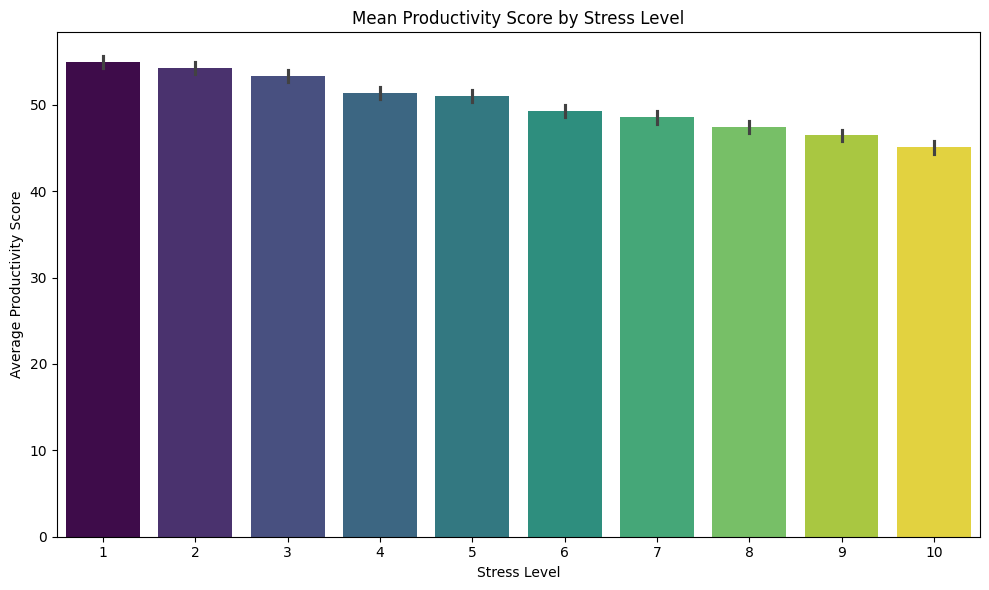

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='stress_level',
    y='productivity_score',
    hue='stress_level',
    palette='viridis',
    legend=False
)
plt.title('Mean Productivity Score by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Average Productivity Score')
plt.tight_layout()
plt.savefig('stress_vs_productivity.png')
plt.show()

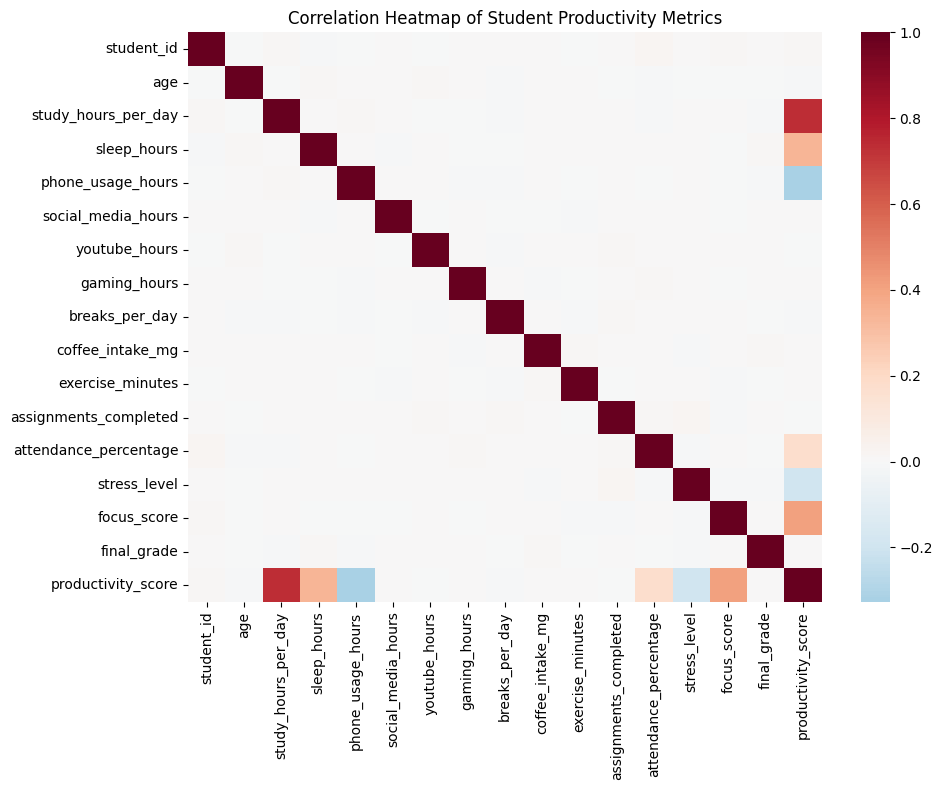

In [ ]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of Student Productivity Metrics')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

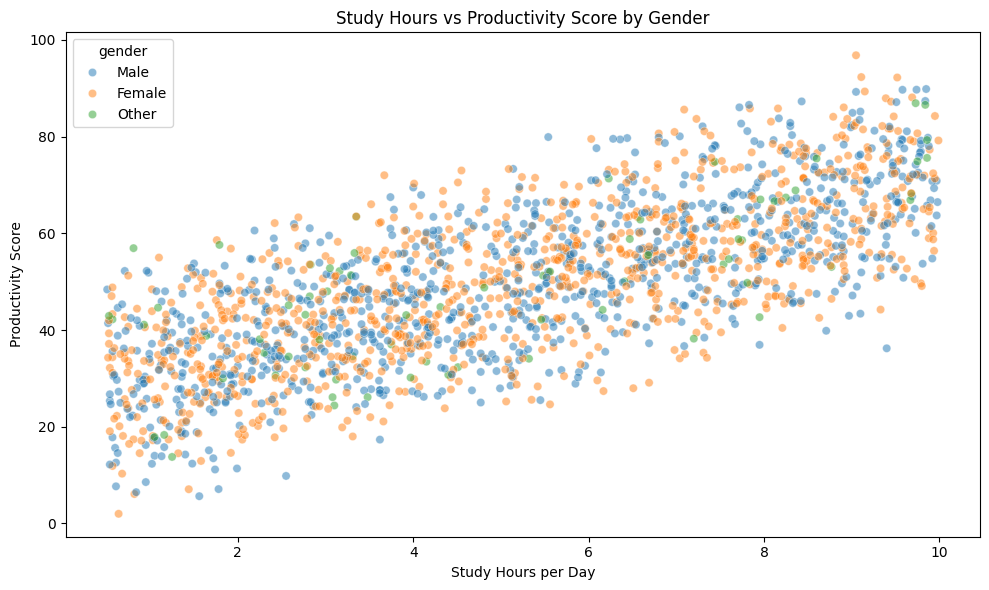

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(2000, len(df))),
    x='study_hours_per_day',
    y='productivity_score',
    hue='gender',
    alpha=0.5
)
plt.title('Study Hours vs Productivity Score by Gender')
plt.xlabel('Study Hours per Day')
plt.ylabel('Productivity Score')
plt.tight_layout()
plt.savefig('study_vs_productivity.png')
plt.show()

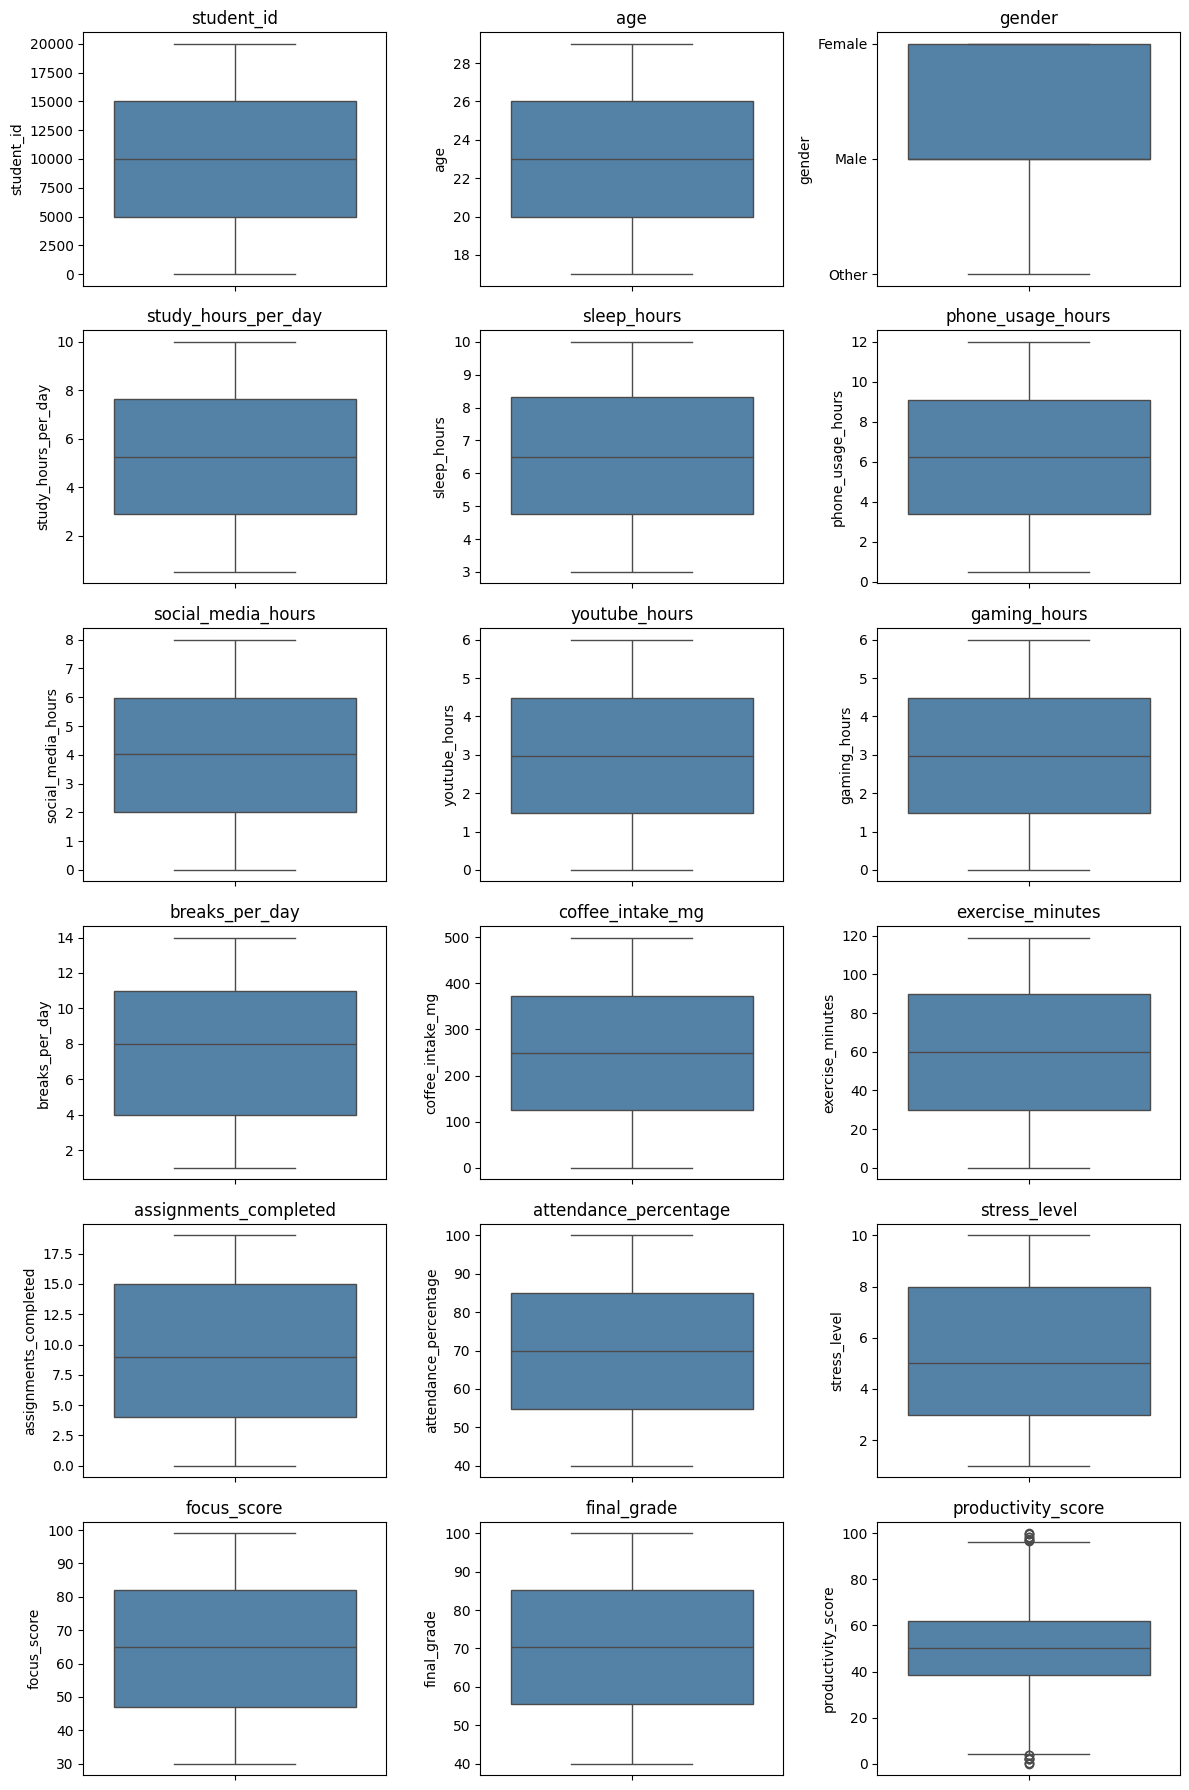

In [ ]:
cols = df.columns
n = len(cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color="steelblue")
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


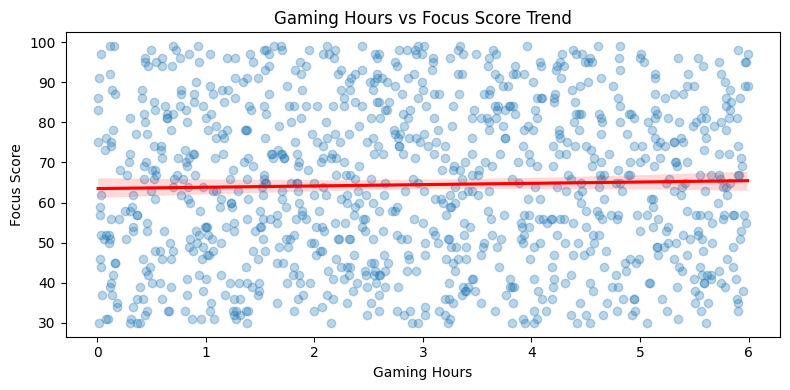

In [ ]:
plt.figure(figsize=(8, 4))
sns.regplot(
    data=df.sample(min(1000, len(df))),
    x='gaming_hours',
    y='focus_score',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)
plt.title('Gaming Hours vs Focus Score Trend')
plt.xlabel('Gaming Hours')
plt.ylabel('Focus Score')
plt.tight_layout()
plt.savefig('gaming_vs_focus.png')
plt.show()

PCA


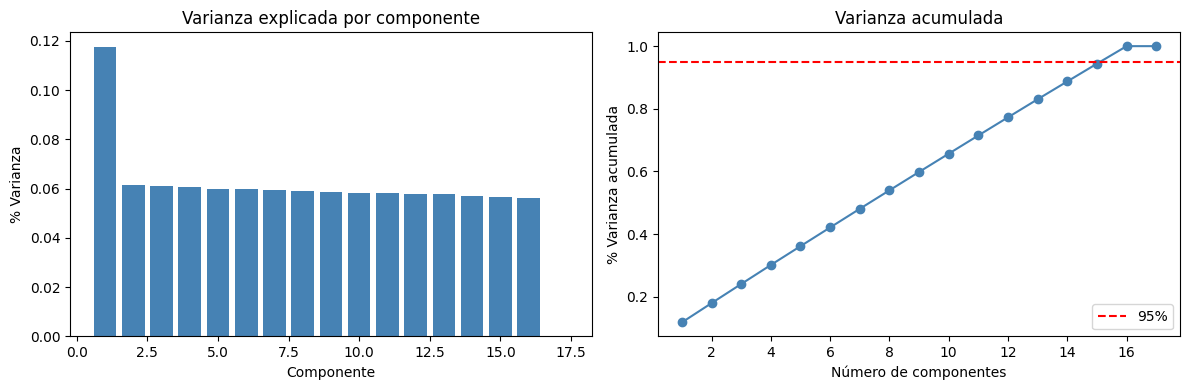

Componentes para explicar 95% de varianza: 16
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.470546 -0.806829 -0.669124 -0.559679  0.220700  0.063774  2.179628   
1 -0.151479  0.078870  0.518735 -0.137403  0.830119 -2.064949 -0.216782   
2 -1.203993 -1.542423 -1.496482 -0.216266 -0.505634  1.096922  0.913931   
3 -2.718866 -1.469956  0.635592  0.072208  0.648553 -0.358037 -2.159001   
4  0.207082 -2.016659 -0.915774  0.629101  1.063553 -0.516782  1.105032   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  0.259669 -1.163886  0.644930 -1.280586  0.653505  1.432371  0.284351   
1 -0.560813  0.861464 -0.829373 -0.799374  0.341860  0.178679 -1.045985   
2  1.922499 -0.265672  0.717884 -2.056271 -0.846450 -0.103503  1.734992   
3 -0.447144 -1.267417 -0.904675 -0.986271  0.107771  0.068091  0.678412   
4  0.168254 -1.859491  0.394037 -2.119923 -0.673138  0.927942 -0.777171   

       PC15      PC16  
0 -0.652450  1.625456  
1 -1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select only numeric columns for PCA
df_numeric = df.select_dtypes(include=[np.number])

# 1. Estandarizar (importante antes de PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

# 2. Aplicar PCA
pca = PCA()
df_pca = pca.fit_transform(df_scaled)

# 3. Varianza explicada por cada componente
varianza = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)

# 4. Gráfica del codo (cuántos componentes conservar)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(varianza) + 1), varianza, color="steelblue")
axes[0].set_title("Varianza explicada por componente")
axes[0].set_xlabel("Componente")
axes[0].set_ylabel("% Varianza")

axes[1].plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o", color="steelblue")
axes[1].axhline(y=0.95, color="red", linestyle="--", label="95%")
axes[1].set_title("Varianza acumulada")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("% Varianza acumulada")
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. Reducir a n componentes (ej. los que explican 95%)
n_componentes = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"Componentes para explicar 95% de varianza: {n_componentes}")

pca_final = PCA(n_components=n_componentes)
df_reducido = pca_final.fit_transform(df_scaled)
df_reducido = pd.DataFrame(df_reducido, columns=[f"PC{i+1}" for i in range(n_componentes)])
print(df_reducido.head())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X = df.drop(columns=['productivity_score'])
y = df['productivity_score']

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Drop 'student_id' column if it exists in df
if "student_id" in df.columns:
    df = df.drop(columns=["student_id"])

# Encode 'gender' column
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])  # ej. Female=0, Male=1, Other=2 (order depends on unique values found)
print("Clases gender:", le.classes_)

Clases gender: [0 1 2]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # solo transform, no fit!

# Convertir a DataFrame para mantener los nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Train:", X_train_scaled.shape)
print("Test: ", X_test_scaled.shape)

Train: (16000, 16)
Test:  (4000, 16)


--- Performance en el conjunto de PRUEBA ---
R²:   1.0000
MSE:  0.0000
RMSE: 0.0029

--- Performance en el conjunto de ENTRENAMIENTO ---
R²:   1.0000
MSE:  0.0000
RMSE: 0.0029

--- Coeficientes del Modelo ---
                 Variable  Coeficiente
2     study_hours_per_day    11.843251
14            focus_score     6.547794
3             sleep_hours     5.486395
4       phone_usage_hours    -5.350638
13           stress_level    -3.094508
12  attendance_percentage     2.817743
15            final_grade    -0.000026
9        coffee_intake_mg     0.000025
7            gaming_hours     0.000024
11  assignments_completed    -0.000024
6           youtube_hours     0.000019
10       exercise_minutes     0.000016
8          breaks_per_day    -0.000015
0                     age     0.000014
5      social_media_hours    -0.000013
1                  gender     0.000006


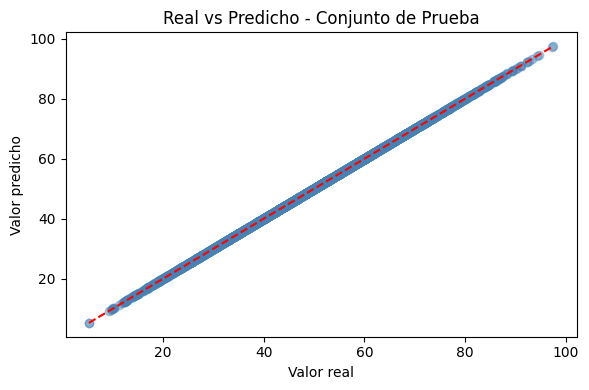

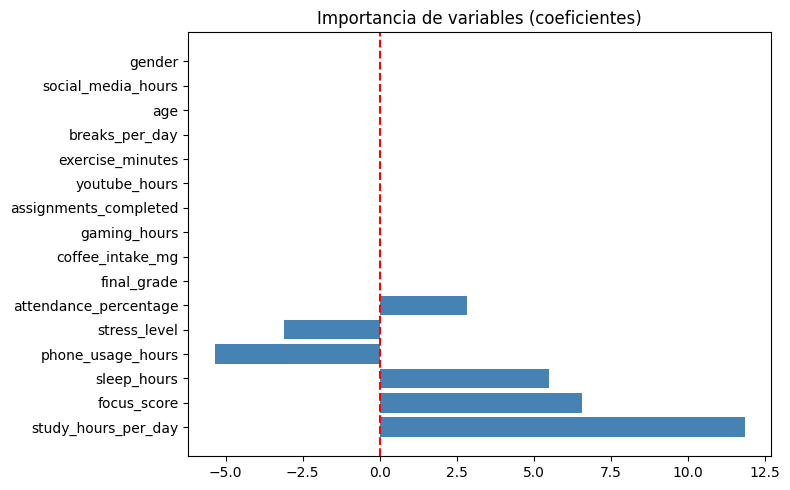

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# 2. Predecir en el conjunto de prueba
y_pred_test = modelo.predict(X_test_scaled)

# 3. Métricas para el conjunto de prueba
print("--- Performance en el conjunto de PRUEBA ---")
print(f"R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"MSE:  {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")

# 4. Predecir en el conjunto de entrenamiento
y_pred_train = modelo.predict(X_train_scaled)

# 5. Métricas para el conjunto de entrenamiento
print("\n--- Performance en el conjunto de ENTRENAMIENTO ---")
print(f"R²:   {r2_score(y_train, y_pred_train):.4f}")
print(f"MSE:  {mean_squared_error(y_train, y_pred_train):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")

# 6. Coeficientes (qué variables influyen más)
coef = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
}).sort_values("Coeficiente", key=abs, ascending=False)
print("\n--- Coeficientes del Modelo ---")
print(coef)

# 7. Gráfica real vs predicho (conjunto de prueba)
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_test, color="steelblue", alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Real vs Predicho - Conjunto de Prueba")
plt.tight_layout()
plt.show()

# 8. Gráfica de coeficientes
plt.figure(figsize=(8, 5))
plt.barh(coef["Variable"], coef["Coeficiente"], color="steelblue")
plt.axvline(x=0, color="red", linestyle="--")
plt.title("Importancia de variables (coeficientes)")
plt.tight_layout()
plt.show()